# Regresión Lineal y Multilineal
**Diplomado Machine Learning | Sesión 3**

**Objetivo principal:** Aprendizaje basado en el error (del EDA a la ecuación, de la ecuación al gradiente).

### Puente desde la clase anterior: EDA completo
La sesión anterior cerró con una tabla de decisiones. Hoy ejecutamos cada una de ellas. Esta sesión es la continuación directa de nuestra historia analítica.

| Hallazgo EDA | Decisión en el modelo (hoy) | Bloque |
| :--- | :--- | :--- |
| `charges` tiene skewness 1.52 | Variable objetivo: `log_charges` | Bloque 1 |
| `smoker` separa el dataset en bandas | Dummy variable (coeficiente más alto esperado) | Bloque 3 |
| `age` y `bmi` correlación positiva | Predictores continuos estandarizados | Bloque 2 y 3 |
| Bimodalidad en fumadores con BMI alto | Término de interacción `smoker_yes × bmi` | Bloque 3 |
| `sex` sin diferencia significativa | Incluir pero esperar $\beta \approx 0$ | Bloque 3 |
| `region` con efecto pequeño | Incluir para no omitir varianza explicable | Bloque 3 |

**Pregunta central de la sesión:** ¿Cómo sabemos que una línea es la "mejor" línea?

In [7]:
# importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configuración visual para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [8]:
# carga de datos
path = 'data/insurance.csv'
df = pd.read_csv(path)

# mostrar las primeras filas del DataFrame
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Bloque 1: El Error Como Protagonista

**¿Qué hace "buena" a una línea?**
Antes de hablar de modelos, hablemos de equivocarnos. Cualquier línea que tracemos sobre nuestros datos cometerá errores. La "mejor" línea es simplemente la que se equivoca menos.

### Conceptos clave:
* **Predicción del modelo:** $\hat{y}_i = \beta_0 + \beta_1x_i$
* **Residual (Error individual):** $e_i = y_i - \hat{y}_i$ (Distancia vertical)
* **Suma de Errores Cuadráticos (SSE):** $SSE = \sum (y_i - \hat{y}_i)^2$
* **Error Cuadrático Medio (MSE):** $MSE = \frac{SSE}{n}$ (¡Esta es nuestra **Función de Costo $J(\beta)$**!)

¿Por qué elevamos el error al cuadrado en lugar de simplemente sumar los errores o usar el valor absoluto?

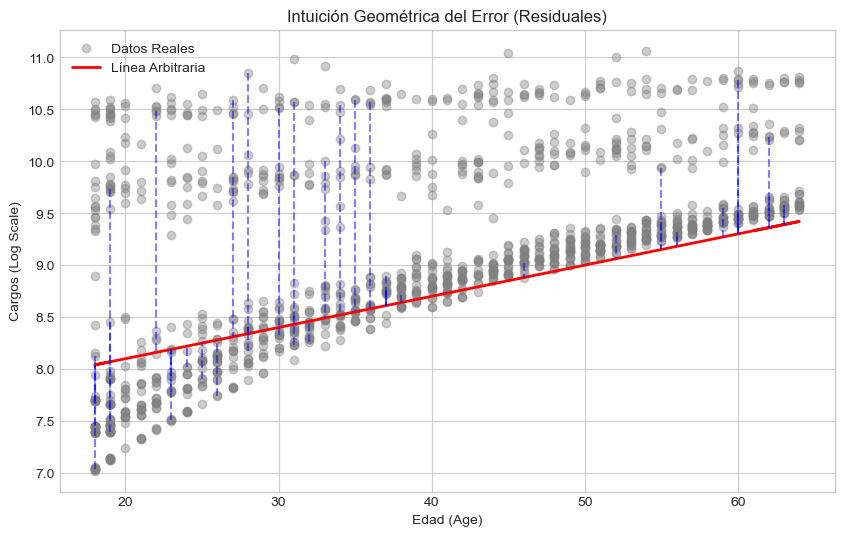

In [ ]:
# 2. Aplicamos la decisión del EDA: log_charges para corregir el skewness
df['log_charges'] = np.log1p(df['charges'])

x = df['age'].values
y = df['log_charges'].values

# 3. Vamos a trazar una línea "arbitraria" para entender el error
beta0_arbitrario = 7.5
beta1_arbitrario = 0.03
y_pred_arbitrario = beta0_arbitrario + beta1_arbitrario * x

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.4, label='Datos Reales', color='gray')
plt.plot(x, y_pred_arbitrario, color='red', linewidth=2, label='Línea Arbitraria')

# Dibujamos los primeros 50 residuales para ilustrar el error
for i in range(50):
    plt.plot([x[i], x[i]], [y[i], y_pred_arbitrario[i]], color='blue', alpha=0.5, linestyle='--')

plt.title('Intuición Geométrica del Error (Residuales)')
plt.xlabel('Edad (Age)')
plt.ylabel('Cargos (Log Scale)')
plt.legend()
plt.show()

### Mini-ejercicio: ¿Qué pendiente minimiza el error?
Ya que el MSE (o SSE) penaliza las distancias, veamos cómo cambia el error al probar tres pendientes diferentes. El modelo es una parábola, y estamos buscando el fondo.

In [ ]:
# Centramos los datos para este ejercicio (separa el efecto de beta0 y beta1)
x_mean, y_mean = x.mean(), y.mean()

print("Comparación de Suma de Errores Cuadráticos (SSE):")
print("-" * 50)

# Evaluamos 3 pendientes candidatas
for beta1 in [0.03, 0.037, 0.05]:
    # Ajustamos el intercepto para que la línea siempre pase por el centro
    beta0 = y_mean - beta1 * x_mean
    
    # Calculamos predicciones
    y_hat = beta0 + beta1 * x
    
    # Calculamos el SSE
    sse = np.sum((y - y_hat)**2)
    
    print(f"Si la pendiente beta_1 es {beta1:.3f} -> SSE = {sse:.2f}")

Comparación de Suma de Errores Cuadráticos (SSE):
--------------------------------------------------
Si la pendiente beta_1 es 0.030 -> SSE = 820.72
Si la pendiente beta_1 es 0.037 -> SSE = 816.88
Si la pendiente beta_1 es 0.050 -> SSE = 878.38


## Bloque 2: Mínimos Cuadrados Ordinarios (OLS) y Regresión Simple

**¿Cómo encontramos el mínimo de la función de costo matemáticamente?**
Mínimos Cuadrados Ordinarios (OLS) es la solución analítica al problema de minimizar el SSE. En lugar de probar valores al azar, utilizamos cálculo diferencial para encontrar el punto exacto donde la pendiente de la función de costo es cero. Es una fórmula cerrada y no un algoritmo iterativo.

**Fórmulas para Regresión Lineal Simple (SLR):**
* Pendiente: $\beta_1 = \frac{\text{Cov}(x,y)}{\text{Var}(x)}$
* Intercepto: $\beta_0 = \bar{y} - \beta_1\bar{x}$ (la línea de regresión siempre pasa por las medias de x e y)

In [16]:
# 1. Cálculo manual usando las fórmulas de OLS
covarianza = np.cov(x, y)[0, 1]
varianza_x = np.var(x, ddof=1)

beta1_manual = covarianza / varianza_x
beta0_manual = y.mean() - beta1_manual * x.mean()

print(f"Cálculo Manual:")
print(f"beta_1 (Pendiente) : {beta1_manual:.5f}")
print(f"beta_0 (Intercepto): {beta0_manual:.5f}\n")

# 2. Verificación usando scikit-learn
sklearn_lr = LinearRegression()
# sklearn requiere que X sea una matriz 2D
X_age = x.reshape(-1, 1) 
sklearn_lr.fit(X_age, y)

print(f"Cálculo con sklearn:")
print(f"beta_1 (Pendiente) : {sklearn_lr.coef_[0]:.5f}")
print(f"beta_0 (Intercepto): {sklearn_lr.intercept_:.5f}")

Cálculo Manual:
beta_1 (Pendiente) : 0.03454
beta_0 (Intercepto): 7.74470

Cálculo con sklearn:
beta_1 (Pendiente) : 0.03454
beta_0 (Intercepto): 7.74470


### Evaluación del primer modelo
Para evaluar qué tan bien se ajusta nuestra línea a los datos, no basta con mirarla. Usaremos dos métricas fundamentales:

**1. Raíz del Error Cuadrático Medio (RMSE):**
Mide el error promedio en las mismas unidades de nuestra variable objetivo.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad \rightarrow \quad RMSE = \sqrt{MSE}$$

**2. Coeficiente de Determinación ($R^2$):**
Mide la proporción de la varianza total de los datos que nuestro modelo logra explicar. Va de 0 a 1 (0% a 100%).
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Métricas del Modelo Lineal (age -> log_charges):
R**2   = 0.2786
RMSE = 0.7806

Interpretación:
Un año más de edad se asocia a un aumento aproximado del 3.51% en los cargos de seguro.


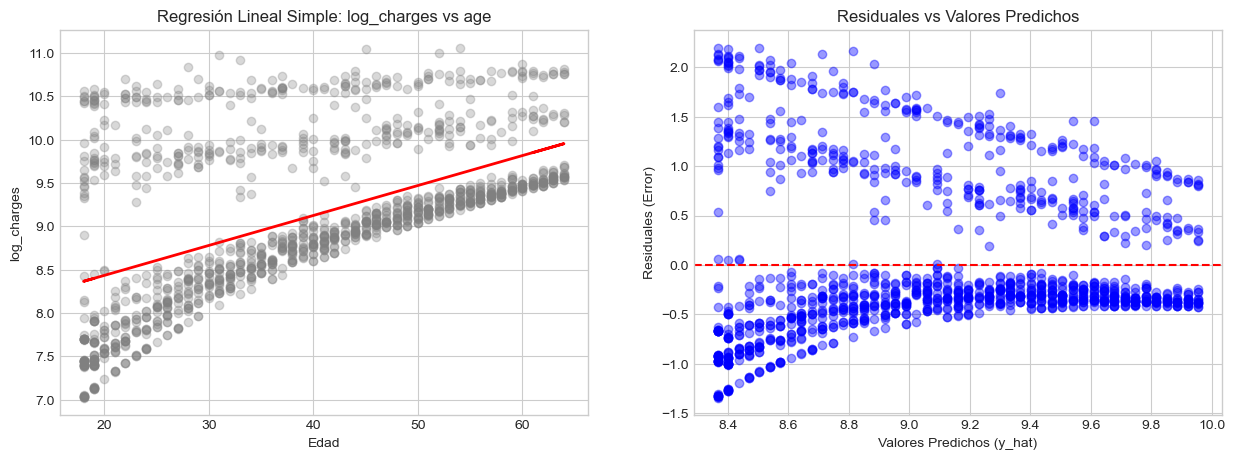

In [18]:
from sklearn.metrics import r2_score, mean_squared_error

# Predicciones del modelo
y_pred = sklearn_lr.predict(X_age)
residuales = y - y_pred

# Métricas de error
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Métricas del Modelo Lineal (age -> log_charges):")
print(f"R**2   = {r2:.4f}")
print(f"RMSE = {rmse:.4f}\n")

# Interpretación en lenguaje de negocio
# Como el target está en escala logarítmica, aplicamos exp() para ver el % de cambio
pct_change = (np.exp(sklearn_lr.coef_[0]) - 1) * 100
print(f"Interpretación:")
print(f"Un año más de edad se asocia a un aumento aproximado del {pct_change:.2f}% en los cargos de seguro.")

# Visualización de la línea ajustada y la distribución de residuales
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Línea de regresión
ax[0].scatter(x, y, alpha=0.3, color='gray')
ax[0].plot(x, y_pred, color='red', linewidth=2)
ax[0].set_title('Regresión Lineal Simple: log_charges vs age')
ax[0].set_xlabel('Edad')
ax[0].set_ylabel('log_charges')

# Gráfico 2: Residuales vs Fitted
ax[1].scatter(y_pred, residuales, alpha=0.4, color='blue')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residuales vs Valores Predichos')
ax[1].set_xlabel('Valores Predichos (y_hat)')
ax[1].set_ylabel('Residuales (Error)')

plt.show()

## Bloque 3: Regresión Multilineal Progresiva

Hasta ahora solo usamos la edad (`age`). El precio del seguro depende de más factores. La Regresión Multilineal agrega más variables y sus respectivas pendientes a nuestra ecuación:

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_px_p$$

Para medir qué tanto mejoran nuestros modelos al agregar variables, nuevamente usaremos las métricas fundamentales.

**1. Error Cuadrático Medio (MSE) y su Raíz (RMSE):**
Mide el error promedio. Usamos la raíz para devolver el error a las unidades originales de nuestro objetivo.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
$$RMSE = \sqrt{MSE}$$

**2. Coeficiente de Determinación ($R^2$):**
Mide el porcentaje de la varianza de los datos que nuestro modelo logra explicar. Va de 0 a 1.
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

### ¿Por qué transformamos los datos antes del modelo?

Antes de pasar los datos a la ecuación $\hat{y} = \beta_0 + \beta_1x_1 + \dots + \beta_px_p$, necesitamos traducir la realidad al idioma que entiende el modelo: matemáticas puras. 

#### 1. Variables Categóricas (Dummy Variables)
El modelo no sabe qué significa "fumador" o "noroeste". Solo entiende números. Si asignamos números arbitrarios a las regiones (Ej: Noroeste=1, Sureste=2, Suroeste=3), el modelo interpretará matemáticamente que el Suroeste "vale el triple" que el Noroeste. Esto es un error grave porque las regiones no tienen un orden o jerarquía natural.

**La solución:** Crear variables *Dummy* (One-Hot Encoding). Convertimos cada categoría en una columna de preguntas de Sí/No (1 o 0). 
*Nota:* Siempre eliminamos la primera categoría (`drop_first=True`) para evitar la "trampa de las variables ficticias" (multicolinealidad perfecta). Si no es hombre, el modelo ya sabe matemáticamente que es mujer por descarte.

#### 2. Estandarización de Variables Numéricas
Imagina que predecimos el precio de una casa usando el número de habitaciones (rango 1 a 5) y el tamaño en centímetros cuadrados (rango 100,000 a 500,000). El tamaño tendrá un coeficiente ($\beta$) minúsculo simplemente porque su escala original es enorme.

**¿Por qué estandarizamos?** Para poner a todas las variables numéricas en el mismo terreno de juego. Al estandarizar, los coeficientes $\beta$ se vuelven comparables. Si el $\beta$ de la edad estandarizada es 0.5 y el del BMI es 0.2, podemos afirmar con certeza matemática que la edad tiene mayor peso en la predicción.

**¿Cuándo SÍ y cuándo NO estandarizar?**
* **SÍ:** En modelos basados en distancias (KNN, SVM), modelos que usan penalización (Lasso, Ridge) y modelos que usan Gradiente Descendente (Redes Neuronales, Regresión Lineal optimizada).
* **NO:** En modelos basados en árboles de decisión (Random Forest, XGBoost), ya que estos algoritmos buscan puntos de corte empíricos y la escala no les afecta. La Regresión Lineal por OLS (la que usamos hoy) no requiere estandarización estrictamente para calcular el error, pero la aplicamos hoy por dos razones: interpretar los coeficientes comparativamente y dejar los datos listos para el algoritmo de Gradiente Descendente de la próxima clase.

#### 3. ¿Por qué StandardScaler y no MinMaxScaler?
Existen varias formas de escalar datos. 
* *MinMaxScaler* comprime todos los datos estrictamente entre 0 y 1. Su debilidad es que si hay un valor extremo (outlier), aplasta a todos los demás datos normales en un rango diminuto.
* *StandardScaler (Z-score)* transforma los datos para que tengan una media de 0 y una desviación estándar de 1. No establece un límite estricto, por lo que maneja mejor los valores atípicos (outliers) naturales, como los cargos médicos extremos.

La fórmula de estandarización Z-score es:
$$z = \frac{x - \mu}{\sigma}$$
Donde $x$ es el valor original, $\mu$ es el promedio de esa variable y $\sigma$ es su desviación estándar.

In [20]:
from sklearn.preprocessing import StandardScaler

# 1. Variables Categóricas (Dummies)
# Convertimos las columnas de texto en columnas numéricas de 1s y 0s
df_mlr = pd.get_dummies(df, columns=['smoker', 'sex', 'region'], drop_first=True)

# 2. Estandarización de Variables Continuas
# Ponemos las variables numéricas en la misma escala para comparar justamente sus pendientes
scaler = StandardScaler()
columnas_continuas = ['age', 'bmi', 'children']
df_mlr[['age_s', 'bmi_s', 'children_s']] = scaler.fit_transform(df_mlr[columnas_continuas])

# 3. Término de Interacción
# Multiplicamos la variable de fumador por el bmi estandarizado
df_mlr['smoker_bmi'] = df_mlr['smoker_yes'] * df_mlr['bmi_s']

# Definimos nuestra variable objetivo
y = df_mlr['log_charges']

print("Preparación terminada. Las columnas disponibles son:")
print(list(df_mlr.columns))
display(df_mlr.head())

Preparación terminada. Las columnas disponibles son:
['age', 'bmi', 'children', 'charges', 'log_charges', 'smoker_yes', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest', 'age_s', 'bmi_s', 'children_s', 'smoker_bmi']


,age,bmi,children,charges,log_charges,smoker_yes,sex_male,region_northwest,region_southeast,region_southwest,age_s,bmi_s,children_s,smoker_bmi
0,19,27.900,0,16884.92400,9.734236,True,False,False,False,True,-1.438764,-0.453320,-0.908614,-0.45332
1,18,33.770,1,1725.55230,7.453882,False,True,False,True,False,-1.509965,0.509621,-0.078767,0.00000
2,28,33.000,3,4449.46200,8.400763,False,True,False,True,False,-0.797954,0.383307,1.580926,0.00000
3,33,22.705,0,21984.47061,9.998137,False,True,True,False,False,-0.441948,-1.305531,-0.908614,-0.00000
4,32,28.880,0,3866.85520,8.260455,False,True,True,False,False,-0.513149,-0.292556,-0.908614,-0.00000


In [21]:
# Revisemos la estadistica descriptiva de las nuevas variables
print("Estadística descriptiva de las variables estandarizadas e interacción:")
display(df_mlr[['age_s', 'bmi_s', 'children_s', 'smoker_bmi']].describe())

Estadística descriptiva de las variables estandarizadas e interacción:


,age_s,bmi_s,children_s,smoker_bmi
count,1.338000e+03,1.338000e+03,1.338000e+03,1338.000000
mean,-1.805565e-16,-2.124194e-16,-5.576008e-17,0.001513
std,1.000374e+00,1.000374e+00,1.000374e+00,0.468393
min,-1.509965e+00,-2.412011e+00,-9.086137e-01,-2.209416
25%,-8.691547e-01,-7.164063e-01,-9.086137e-01,0.000000
50%,-1.474046e-02,-4.320880e-02,-7.876719e-02,0.000000
75%,8.396738e-01,6.611572e-01,7.510793e-01,0.000000
max,1.765289e+00,3.685522e+00,3.240619e+00,3.595298


### Construcción Incremental del Modelo
Vamos a agregar las variables paso a paso. Observaremos cómo cambia el $R^2$ y el RMSE en cada iteración para entender el peso real de cada factor.

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

# Definimos las variables para cada etapa
var_m1 = ['age_s']
var_m2 = ['age_s', 'bmi_s']
var_m3 = ['age_s', 'bmi_s', 'smoker_yes']
var_m4 = ['age_s', 'bmi_s', 'smoker_yes', 'smoker_bmi']
var_m5 = ['age_s', 'bmi_s', 'smoker_yes', 'smoker_bmi', 'children_s', 'sex_male', 
          'region_northwest', 'region_southeast', 'region_southwest']

lista_modelos = [
    ("M1 (Solo Edad)", var_m1),
    ("M2 (+ BMI)", var_m2),
    ("M3 (+ Fumador)", var_m3),
    ("M4 (+ Interacción Fumador*BMI)", var_m4),
    ("M5 (Modelo Completo)", var_m5)
]

print(f"{'Modelo':<35} | {'R2':<8} | {'RMSE':<8}")
print("-" * 55)

modelo_actual = LinearRegression()

for nombre, variables in lista_modelos:
    X_temp = df_mlr[variables]
    
    modelo_actual.fit(X_temp, y)
    
    y_pred_temp = modelo_actual.predict(X_temp)
    r2_temp = r2_score(y, y_pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y, y_pred_temp))
    
    print(f"{nombre:<35} | {r2_temp:.4f}   | {rmse_temp:.4f}")

Modelo                              | R2       | RMSE    
-------------------------------------------------------
M1 (Solo Edad)                      | 0.2786   | 0.7806
M2 (+ BMI)                          | 0.2843   | 0.7775
M3 (+ Fumador)                      | 0.7446   | 0.4644
M4 (+ Interacción Fumador*BMI)      | 0.7589   | 0.4512
M5 (Modelo Completo)                | 0.7835   | 0.4276


### Interpretación del Modelo Completo (M5)
Extraeremos los coeficientes del modelo M5 para identificar cuáles variables tienen el mayor impacto numérico sobre los cargos médicos.

In [27]:
# Ajustamos el modelo final con todas las variables
X_full = df_mlr[var_m5]
modelo_final = LinearRegression()
modelo_final.fit(X_full, y)

# Armamos las listas de nombres y valores
nombres = ['Intercepto'] + var_m5
valores = [modelo_final.intercept_] + list(modelo_final.coef_)

# Creamos un DataFrame para visualizar los coeficientes
df_coeficientes = pd.DataFrame({
    'Variable': nombres,
    'Coeficiente': valores
})

# Calculamos el valor absoluto para ordenar por impacto real (columna temporal)
df_coeficientes['Impacto_Absoluto'] = df_coeficientes['Coeficiente'].abs()
df_coeficientes = df_coeficientes.sort_values(by='Impacto_Absoluto', ascending=False)
# eliminamos la columna temporal de impacto absoluto para mostrar solo lo relevante
df_coeficientes = df_coeficientes.drop(columns=['Impacto_Absoluto'])

print("Coeficientes del Modelo Completo:")
print("-" * 40)
display(df_coeficientes)

Coeficientes del Modelo Completo:
----------------------------------------


,Variable,Coeficiente
0,Intercepto,8.919133
3,smoker_yes,1.553706
1,age_s,0.488587
4,smoker_bmi,0.277807
8,region_southeast,-0.162684
9,region_southwest,-0.137481
5,children_s,0.124261
6,sex_male,-0.087035
7,region_northwest,-0.071117
2,bmi_s,0.020760


## Bloque 4: Diagnóstico del Modelo

Tener un $R^2$ alto no significa automáticamente que el modelo sea válido para hacer inferencias o tomar decisiones. La verdadera validación del modelo se encuentra en el comportamiento de sus errores (los residuales).

Para que un modelo de Regresión Lineal por Mínimos Cuadrados Ordinarios (OLS) sea completamente confiable, debe cumplir con **4 supuestos fundamentales**:

1. **Linealidad:** La relación entre las variables independientes y la variable objetivo es verdaderamente lineal.
2. **Homocedasticidad:** La varianza de los errores es constante. Es decir, el modelo no se equivoca de forma más drástica al predecir valores altos frente a valores bajos.
3. **Independencia:** Los residuales no tienen patrones entre sí (importante sobre todo en series de tiempo).
4. **Normalidad:** Los residuales siguen una distribución normal (forma de campana) centrada en cero.

Vamos a generar gráficos para comprobar visualmente la **homocedasticidad** y la **normalidad**.

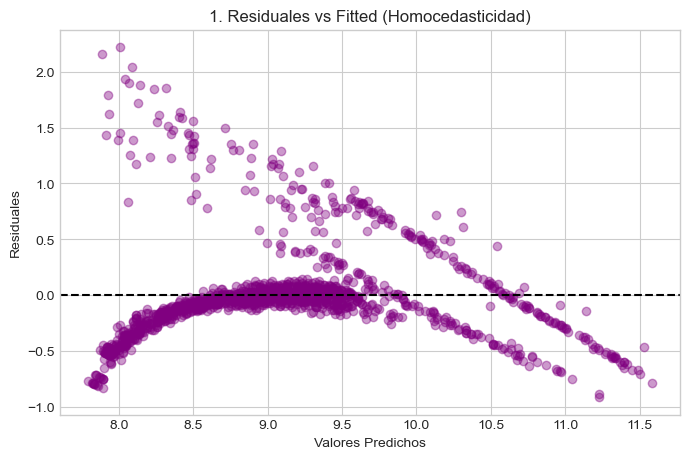

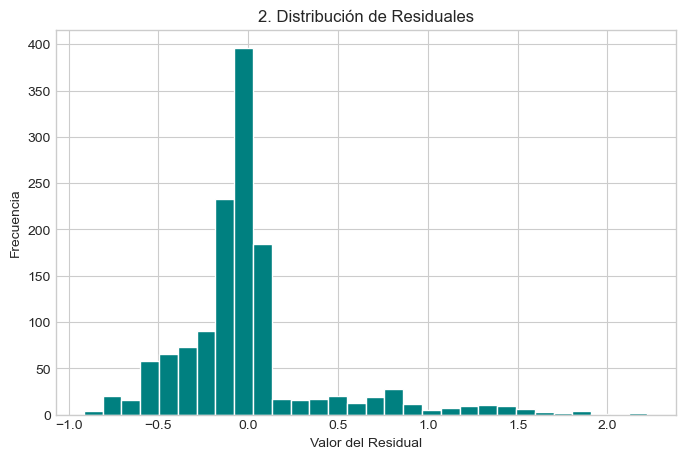

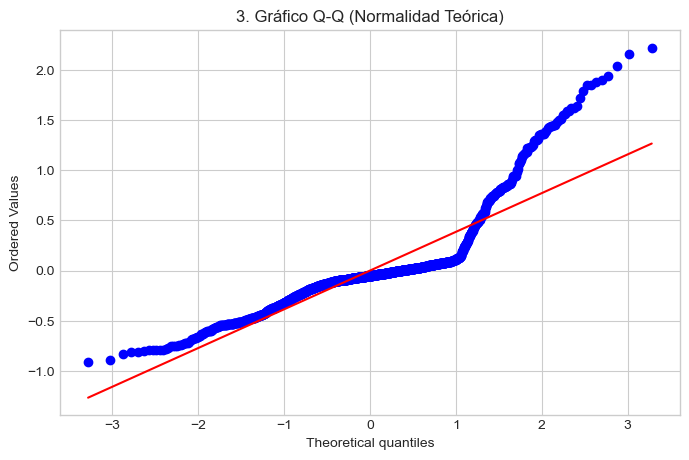

In [28]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calculamos las predicciones y residuales del modelo completo (M5)
y_pred_final = modelo_final.predict(X_full)
residuales_finales = y - y_pred_final

# --- Gráfico 1: Residuales vs Valores Predichos (Prueba de Homocedasticidad) ---
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_final, residuales_finales, color='purple', alpha=0.4)
plt.axhline(0, color='black', linestyle='--')
plt.title("1. Residuales vs Fitted (Homocedasticidad)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuales")
plt.show()
# Interpretación: Buscamos una nube aleatoria de puntos. Si vemos un "embudo", 
# significa que hay heterocedasticidad (el error crece con el valor predicho).

# --- Gráfico 2: Histograma de Residuales (Prueba de Normalidad) ---
plt.figure(figsize=(8, 5))
plt.hist(residuales_finales, bins=30, color='teal', edgecolor='white')
plt.title("2. Distribución de Residuales")
plt.xlabel("Valor del Residual")
plt.ylabel("Frecuencia")
plt.show()
# Interpretación: Buscamos que tenga forma de Campana de Gauss centrada en 0.

# --- Gráfico 3: Q-Q Plot (Prueba estricta de Normalidad) ---
plt.figure(figsize=(8, 5))
stats.probplot(residuales_finales, dist="norm", plot=plt)
plt.title("3. Gráfico Q-Q (Normalidad Teórica)")
plt.show()
# Interpretación: Los puntos deben seguir la línea roja. Las desviaciones en los 
# extremos indican que el modelo falla en predecir los casos más atípicos.

### Métricas Avanzadas: R² Ajustado y Error Absoluto (MAE)

En la regresión múltiple, el $R^2$ normal tiene un defecto matemático: siempre aumenta o se mantiene igual al agregar nuevas variables, incluso si son completamente inútiles. Esto puede hacernos creer falsamente que el modelo está mejorando.

Para evitar este engaño, introducimos dos métricas adicionales de diagnóstico:

**1. Coeficiente de Determinación Ajustado ($R^2_{adj}$):**
Esta métrica penaliza matemáticamente la inclusión de variables que no aportan un valor explicativo real, ajustando el puntaje según la cantidad de datos ($n$) y la cantidad de variables ($p$).
$$R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$

**2. Error Absoluto Medio (MAE):**
El RMSE eleva los errores al cuadrado, lo que castiga fuertemente a los outliers (datos atípicos). El MAE, al usar el valor absoluto, nos da una medida de error más robusta y más directa para comunicar a equipos de negocio.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

In [29]:
from sklearn.metrics import mean_absolute_error

# Cálculos base
n = len(y) # Número de observaciones
p = X_full.shape[1] # Número de variables predictoras

# Métricas
r2_final = r2_score(y, y_pred_final)
r2_ajustado = 1 - (1 - r2_final) * (n - 1) / (n - p - 1)
rmse_final = np.sqrt(mean_squared_error(y, y_pred_final))
mae_final = mean_absolute_error(y, y_pred_final)

print("Reporte Final de Métricas (Modelo M5):")
print("-" * 40)
print(f"R² Normal      : {r2_final:.4f}")
print(f"R² Ajustado    : {r2_ajustado:.4f}")
print(f"RMSE           : {rmse_final:.4f} (Escala logarítmica)")
print(f"MAE            : {mae_final:.4f} (Escala logarítmica)")

Reporte Final de Métricas (Modelo M5):
----------------------------------------
R² Normal      : 0.7835
R² Ajustado    : 0.7821
RMSE           : 0.4276 (Escala logarítmica)
MAE            : 0.2615 (Escala logarítmica)


El $R^2$ de 0.7835 indica que el modelo explica aproximadamente el 78% de la varianza en los cargos médicos. La mínima diferencia con el $R^2$ ajustado (0.7821) confirma que no estamos sufriendo un sobreajuste severo por haber incluido demasiadas variables.
#### Diagnóstico Visual (Violación de Supuestos):
1. ***Homocedasticidad (Residuales vs Fitted)***: El supuesto de varianza constante se viola claramente. En lugar de una nube aleatoria centrada en cero, los puntos forman líneas con pendiente negativa y agrupaciones separadas. El modelo está fallando en capturar dinámicas subyacentes (probablemente relaciones no lineales que la regresión múltiple estándar no puede modelar).
2. ***Normalidad (Histograma y Q-Q Plot)***: Los residuales no siguen una distribución normal perfecta. El histograma muestra una asimetría hacia la izquierda y el gráfico Q-Q evidencia una desviación drástica en la cola inferior. El modelo sobrestima significativamente los cargos en ciertos rangos extremos.

## Cierre: El límite de OLS y la semilla del Gradiente

El modelo que construimos hoy nos dio un $R^2$ del 78%, pero las gráficas de diagnóstico nos demostraron que una línea recta tiene límites para entender dinámicas complejas. 

Además de los problemas teóricos (violación de supuestos), la solución analítica de Mínimos Cuadrados Ordinarios (OLS) tiene un problema práctico grave: **no escala**.

La fórmula matricial de OLS es $\beta = (X^T X)^{-1} X^T y$. Invertir una matriz $(X^T X)$ es un proceso muy costoso a nivel computacional. Con 1,338 filas (nuestro dataset actual), la computadora lo resuelve en milisegundos. Si tuviéramos 50 millones de pacientes y 2,000 variables, el cálculo requeriría una memoria prohibitiva y podría colapsar el sistema.

**¿Qué hacemos cuando no podemos usar la fórmula cerrada?**
Volvemos a la intuición geométrica del Bloque 1. Recordamos que la función de costo (MSE) forma una parábola o un "bowl" en múltiples dimensiones. Si no podemos calcular directamente el fondo del bowl, podemos "caminar" hacia él paso a paso. Este algoritmo iterativo se llama **Gradiente Descendente**.

Esta será la ecuación central de nuestra próxima sesión:
$$\beta_j \leftarrow \beta_j - \alpha \frac{\partial J(\beta)}{\partial \beta_j}$$

Donde:
* $\alpha$ (Alpha): Tasa de aprendizaje o tamaño del paso.
* $\frac{\partial J(\beta)}{\partial \beta_j}$: La derivada parcial de la función de costo respecto a cada parámetro (la pendiente del terreno en ese punto exacto).

### Tareas para la próxima sesión
1. **Implementar GD en 1D:** Intentar escribir en Python un bucle `for` simple que actualice el valor de $\beta_1$ utilizando la ecuación anterior para el modelo de edad vs cargos.
2. **Reflexión:** Si el Gradiente Descendente llega al fondo de la función de costo, ¿el resultado final de $\beta$ será exactamente igual al que calculamos hoy con OLS o habrá variaciones?